<div class="alert alert-block alert-success">
<h1> DATA MINING - PROJECT </h1>
<h2> Group 19 </h2>
<h3> 20225/2026 </h3>

Student Name - António Parafita <br>
Student id - 20250363 <br>

Student Name - Diogo Montenegro <br>
Student id - 20250491 <br>

Student Name - Francisco <br>
Student id - 20250482 <br>

## **Index**<br>



<a class="anchor" id="1st-bullet">    </a>
# 1. Imports

<a class="anchor" id="2st-bullet">    </a>
## 1.1 Import libraries

In [257]:
import sqlite3
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from itertools import product

#maps
import folium
from folium.plugins import MarkerCluster
from folium.plugins import HeatMap
from IPython.display import IFrame

from ydata_profiling import ProfileReport

# for better resolution plots
%config InlineBackend.figure_format = 'retina' # optionally, you can change 'svg' to 'retina'

# Setting seaborn style
sns.set_style("ticks")

## Functions

In [258]:
def detect_outliers_iqr(data, threshold=0.01):
    """
    Detects outliers in numerical columns using the Interquartile Range (IQR) method
    and optionally reports columns where the percentage of outliers exceeds a threshold.
    A boxplot highlighting the outliers is also generated for each column.

    Parameters:
        data (DataFrame): 
            The input dataset containing numerical variables.
    """
    outlier_summary = []
    for col in data.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Identify outliers
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
        n_outliers = len(outliers)
        pct_outliers = 100 * n_outliers / len(data)
        # Print summary
        print(f"Column: {col} - Number of Outliers: {n_outliers}")
        print(f"Column: {col} - % of Outliers: {pct_outliers:.2f}%\n")
        # Add to list if exceeds threshold
        if pct_outliers > threshold * 100:
            outlier_summary.append((col, n_outliers, pct_outliers))
        # Plot boxplot
        plt.figure(figsize=(8, 5))
        sns.boxplot(x=data[col], color='orange')
        sns.stripplot(x=outliers, color='red', size=4, label='Outliers')
        plt.title(f'Boxplot with Outliers for {col}', fontsize=14)
        plt.legend()
        plt.show()
    return pd.DataFrame(outlier_summary, columns=['Column', 'Num_Outliers', 'Pct_Outliers'])

<a class="anchor" id="3st-bullet">    </a>
## 1.2 Import Data

In [259]:
customers = pd.read_csv('data/DM_AIAI_CustomerDB.csv', index_col = 0)
flights = pd.read_csv('data/DM_AIAI_FlightsDB.csv')

In [260]:
df_c = customers.copy()

In [261]:
df_f = flights.copy()

## 2 Data Preprocessing


### 2.1 Data types

**Customers dataset**

In [262]:
df_c.sample(10)

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
9491,738431,Tyron,Brulotte,Tyron Brulotte,Canada,Nova Scotia,Halifax,44.648766,-63.575237,B3J 9S2,male,High School or Below,Suburban,27229.0,Single,Nova,2/25/2017,NaN,18745.40,Standard
537,481857,Rowena,Youngkin,Rowena Youngkin,Canada,New Brunswick,Fredericton,45.963589,-66.643112,E3B 2H2,male,Bachelor,Suburban,54050.0,Married,Star,5/28/2017,NaN,4746.76,Standard
4745,197608,Jerilyn,Ceranski,Jerilyn Ceranski,Canada,Saskatchewan,Regina,50.445210,-104.618900,S6J 3G0,male,College,Rural,0.0,Single,Nova,5/18/2017,NaN,3063.11,Standard
16521,632199,Nidia,Toher,Nidia Toher,Canada,Quebec,Montreal,45.501690,-73.567253,H4G 3T4,male,Bachelor,Rural,36032.0,Divorced,Star,4/30/2019,NaN,19690.44,Standard
9662,702522,Kandace,Sieg,Kandace Sieg,Canada,Ontario,Toronto,43.653225,-79.383186,P1L 8X8,male,Bachelor,Urban,89918.0,Divorced,Nova,7/29/2018,NaN,23207.25,Standard
10507,804402,Donetta,Pinna,Donetta Pinna,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,Bachelor,Rural,83140.0,Married,Star,2/27/2019,NaN,2430.51,Standard
9177,263267,Clifton,Cillis,Clifton Cillis,Canada,Ontario,Sudbury,46.522099,-80.953033,M5V 1G5,male,Doctor,Urban,16181.0,Divorced,Nova,6/26/2016,4/29/2018,13736.13,Standard
7290,781052,Denisha,Yant,Denisha Yant,Canada,British Columbia,Vancouver,49.282730,-123.120740,V1E 4R6,female,College,Rural,0.0,Single,Nova,12/13/2017,NaN,6503.14,Standard
3060,442249,Karoline,Odem,Karoline Odem,Canada,Ontario,Toronto,43.653225,-79.383186,M2M 7K8,female,Bachelor,Suburban,63528.0,Divorced,Aurora,4/8/2019,NaN,10115.45,Standard
3670,939431,Ellamae,Egner,Ellamae Egner,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,Bachelor,Suburban,70140.0,Married,Aurora,4/15/2021,NaN,16068.35,2021 Promotion


In [263]:
df_c.dtypes

Loyalty#                     int64
First Name                  object
Last Name                   object
Customer Name               object
Country                     object
Province or State           object
City                        object
Latitude                   float64
Longitude                  float64
Postal code                 object
Gender                      object
Education                   object
Location Code               object
Income                     float64
Marital Status              object
LoyaltyStatus               object
EnrollmentDateOpening       object
CancellationDate            object
Customer Lifetime Value    float64
EnrollmentType              object
dtype: object

In [264]:
df_f.sample(10)

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
596055,342738,2019,12,12/1/2019,0.0,0.0,0.0,0.0,0.0,0.0
70043,145480,2020,2,2/1/2020,6.0,1.0,4071.0,407.0,0.0,0.0
303607,836443,2020,12,12/1/2020,5.0,5.0,14953.0,1495.0,0.0,0.0
350251,256467,2020,9,9/1/2020,0.0,0.0,0.0,0.0,0.0,0.0
93495,117333,2021,11,11/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
104283,757446,2021,11,11/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
577270,242203,2019,11,11/1/2019,0.0,0.0,0.0,0.0,0.0,0.0
491651,182459,2019,6,6/1/2019,0.0,0.0,0.0,0.0,0.0,0.0
588570,839694,2019,11,11/1/2019,0.0,0.0,0.0,0.0,0.0,0.0
105079,897904,2021,11,11/1/2021,0.0,0.0,0.0,0.0,0.0,0.0


In [265]:
df_f.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
YearMonthDate                object
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object

**Set 'EnrollmentDateOpening', 'CancellationDate' & 'YearMonthDate' type to *datetime***

In [266]:
df_c['EnrollmentDateOpening'] = pd.to_datetime(
    df_c['EnrollmentDateOpening'],
    errors='coerce'
)

df_c['CancellationDate'] = pd.to_datetime(
    df_c['CancellationDate'],
    errors='coerce'
)

df_f['YearMonthDate'] = pd.to_datetime(
    df_f['YearMonthDate'],
    errors='coerce'
)

**Changing data type of numFlights & numFlightsWithCompanions to int**

In [267]:
df_f['NumFlights'] = df_f['NumFlights'].astype(int)
df_f['NumFlightsWithCompanions'] = df_f['NumFlightsWithCompanions'].astype(int)

**Changing income to int**

In [268]:
df_c["Income"] = df_c["Income"].astype("Int64")

Lets create 2 lists for each df, to store the numerical and categorical features separatly.

In [269]:
c_metric = ['Income', 'Customer Lifetime Value','Latitude','Longitude']
c_categ = ['First Name', 'Last Name','Customer Name','Country', 'Province or State', 'City','Postal code','Gender','Education','Location Code','Marital Status',
          'LoyaltyStatus','EnrollmentType' ]
f_metric = ['Year','Month','NumFlights','NumFlightsWithCompanions','DistanceKM','PointsAccumulated','PointsRedeemed','DollarCostPointsRedeemed']

## Duplicates

In [270]:
# replace "" by nans
df_c.replace("", np.nan, inplace=True)
# count of missing values
df_c.isna().sum()

Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14613
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

In [271]:
# replace "" by nans
df_f.replace("", np.nan, inplace=True)

# count of missing values
df_f.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

**Checking for duplicates and dropping them**

In [272]:
df_c.duplicated().sum()

np.int64(0)

In [273]:
df_f.duplicated().sum()

np.int64(2903)

In [274]:
df_f = df_f.drop_duplicates()
df_f.duplicated().sum()

np.int64(0)

— We should drop them because a customer shouldn't have the same month of the same year registered more than once

**Checking if Loyalty# has repeated values**

In [275]:
# How many Loyalty# have duplicates?
print(df_c['Loyalty#'].value_counts()[df_c['Loyalty#'].value_counts() > 1].size)
print(df_f['Loyalty#'].value_counts()[df_f['Loyalty#'].value_counts() > 1].size)

163
16737


In [276]:
#checking if there are extra ids in flights dataset
extra_ids = set(df_f['Loyalty#']) - set(df_c['Loyalty#'])
print( len(extra_ids))

0


In [277]:
#checking how many customer ids don't have flights
ids_without_flights = set(df_c['Loyalty#']) - set(df_f['Loyalty#'])
print( len(ids_without_flights))


20


In [278]:
# 1) Find problematic Loyalty# values in the df_c (appear more than once)
dupe_ids_cust = (
    df_c['Loyalty#']
    .value_counts()
    .loc[lambda s: s > 1]
    .index
)

# 2) Completely remove those values from both datasets
df_c = df_c[~df_c['Loyalty#'].isin(dupe_ids_cust)].copy()
df_f = df_f[~df_f['Loyalty#'].isin(dupe_ids_cust)].copy()

**Checking zeros and negative values**

In [279]:
# Check for zeros in customer dataset
(df_c == 0).sum()

Loyalty#                      0
First Name                    0
Last Name                     0
Customer Name                 0
Country                       0
Province or State             0
City                          0
Latitude                      0
Longitude                     0
Postal code                   0
Gender                        0
Education                     0
Location Code                 0
Income                     4198
Marital Status                0
LoyaltyStatus                 0
EnrollmentDateOpening         0
CancellationDate              0
Customer Lifetime Value       0
EnrollmentType                0
dtype: Int64

In [280]:
# Check for negative values in customer dataset
(df_c.select_dtypes(include=['number']) < 0).sum()

Loyalty#                       0
Latitude                       0
Longitude                  16594
Income                         0
Customer Lifetime Value        0
dtype: Int64

In [281]:
# Check for zeros in flights dataset
(df_f == 0).sum()

Loyalty#                         0
Year                             0
Month                            0
YearMonthDate                    0
NumFlights                  303071
NumFlightsWithCompanions    447294
DistanceKM                  291496
PointsAccumulated           291496
PointsRedeemed              561780
DollarCostPointsRedeemed    561780
dtype: int64

In [282]:
# Check for negative values in flights dataset
(df_f.select_dtypes(include=['number']) < 0).sum()

Loyalty#                    0
Year                        0
Month                       0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

## Feature Creation

**"Days_sub" - number of days subscribed in program**

In [283]:
# Converte to datetime
df_c["EnrollmentDateOpening"] = pd.to_datetime(df_c["EnrollmentDateOpening"], errors="coerce")
df_c["CancellationDate"] = pd.to_datetime(df_c["CancellationDate"], errors="coerce")

# Assume that "today" is the last recent date found in dataset
max_date = max(df_c["EnrollmentDateOpening"].max(), df_c["CancellationDate"].max())
print(f"Most recent date extracted: {max_date}\n")

# Compute difference in days
df_c["Days_sub"] = (
    df_c["CancellationDate"].fillna(max_date) - df_c["EnrollmentDateOpening"]
).dt.days

# If negative value, assume there was a switch of dates 
df_c["Days_sub"] = df_c["Days_sub"].abs()
# Description (no negative value)
print(df_c["Days_sub"].describe())

Most recent date extracted: 2021-12-30 00:00:00

count    16594.000000
mean      1098.976076
std        737.900363
min          0.000000
25%        389.000000
50%       1015.000000
75%       1744.000000
max       2465.000000
Name: Days_sub, dtype: float64


In [284]:
c_metric.append('Days_sub')


Since we've created this new feature, we can now drop both **"EnrollmentDateOpening"** and **"CancellationDate"** since having this have the same meaning.

In [285]:
df_c = df_c.drop(['EnrollmentDateOpening', 'CancellationDate'], axis=1)

***AvgFlightDistance_month* — Average distance per flight taken by a customer in a specific month**

In [286]:
df_f['AvgFlightDistance_month'] = np.where(
    df_f['NumFlights'] > 0,
    df_f['DistanceKM'] / df_f['NumFlights'],
    0
)

df_f.sample(10)

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month
497527,493819,2019,6,2019-06-01,11,5,1994.4,199.44,0.0,0.0,181.309091
505924,941621,2019,6,2019-06-01,0,0,0.0,0.00,0.0,0.0,0.000000
192790,478050,2021,9,2021-09-01,13,5,3001.0,300.00,0.0,0.0,230.846154
256690,591576,2021,2,2021-02-01,0,0,0.0,0.00,0.0,0.0,0.000000
236462,203577,2021,4,2021-04-01,2,0,23838.0,2383.00,0.0,0.0,11919.000000
272056,230687,2021,1,2021-01-01,5,4,11957.0,1195.00,0.0,0.0,2391.400000
352722,909238,2020,8,2020-08-01,0,0,0.0,0.00,0.0,0.0,0.000000
167902,282542,2021,10,2021-10-01,11,0,1946.0,194.00,0.0,0.0,176.909091
562128,335671,2019,10,2019-10-01,9,0,4056.3,405.63,0.0,0.0,450.700000
548782,523722,2019,9,2019-09-01,1,0,24831.9,2483.19,0.0,0.0,24831.900000


In [287]:
f_metric.append('AvgFlightDistance_month')


## Dealing with outliers

Column: Income - Number of Outliers: 0
Column: Income - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_43260\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


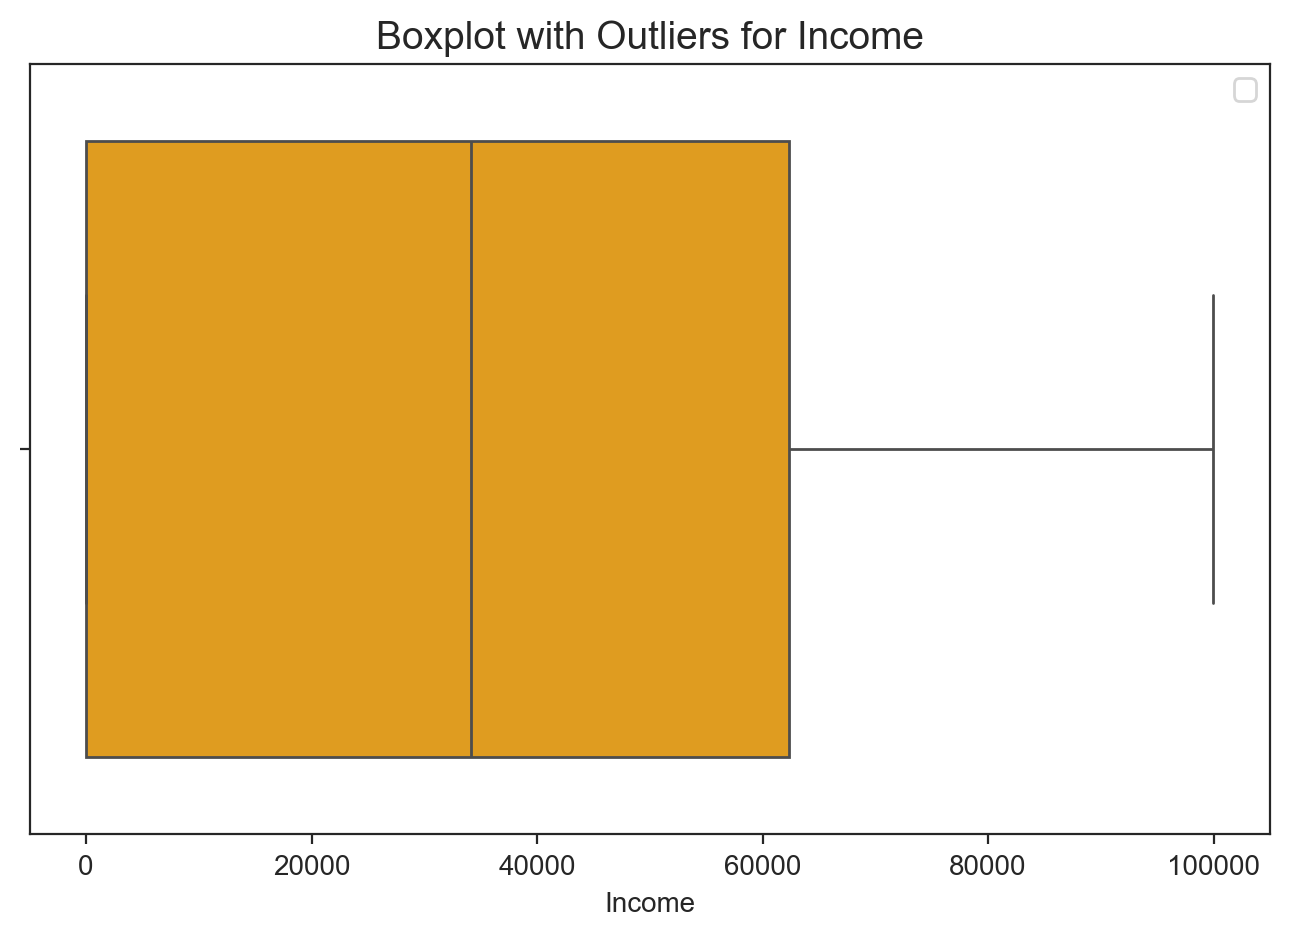

Column: Customer Lifetime Value - Number of Outliers: 1460
Column: Customer Lifetime Value - % of Outliers: 8.80%



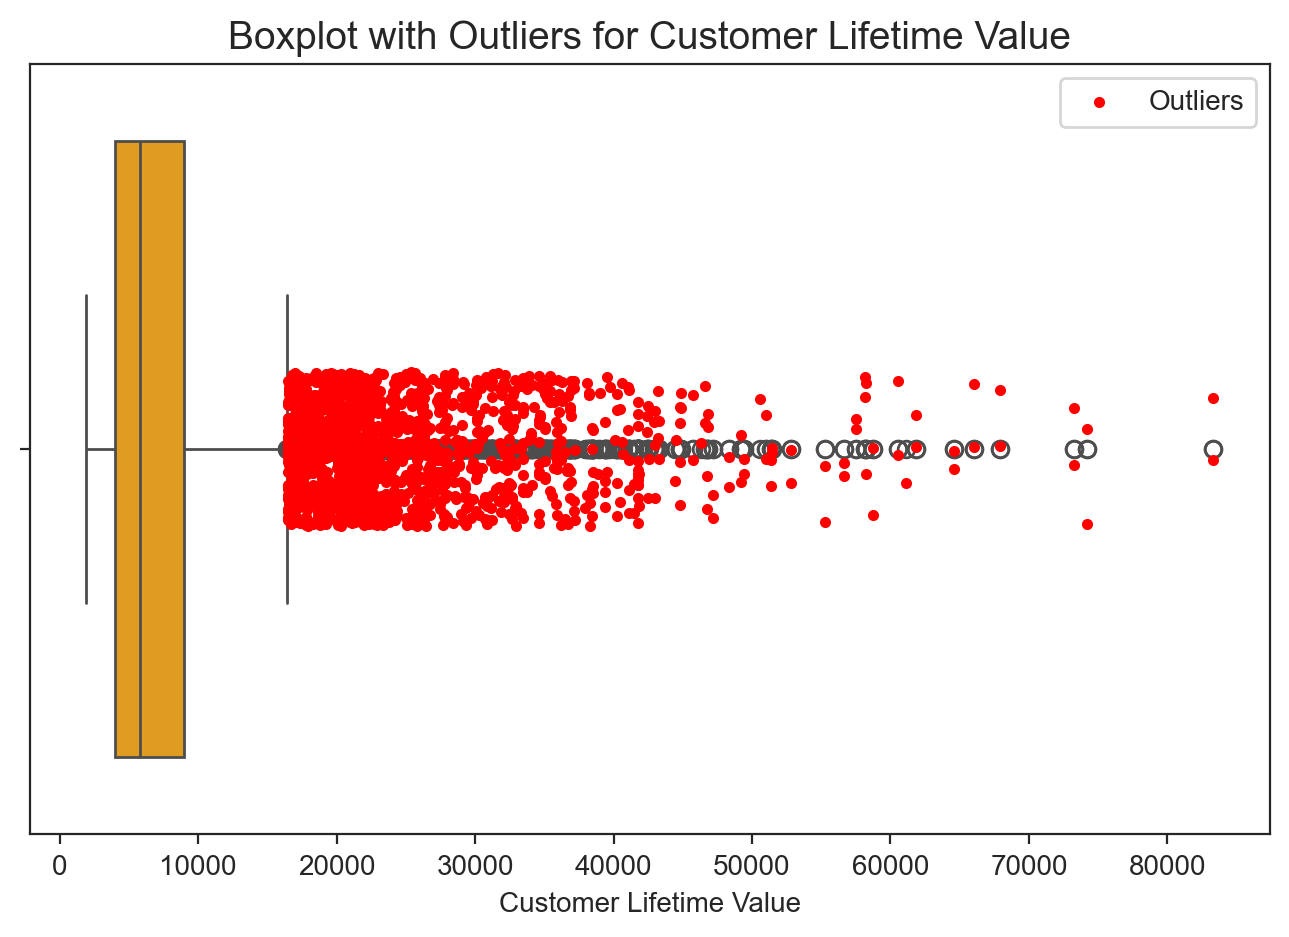

Column: Latitude - Number of Outliers: 108
Column: Latitude - % of Outliers: 0.65%



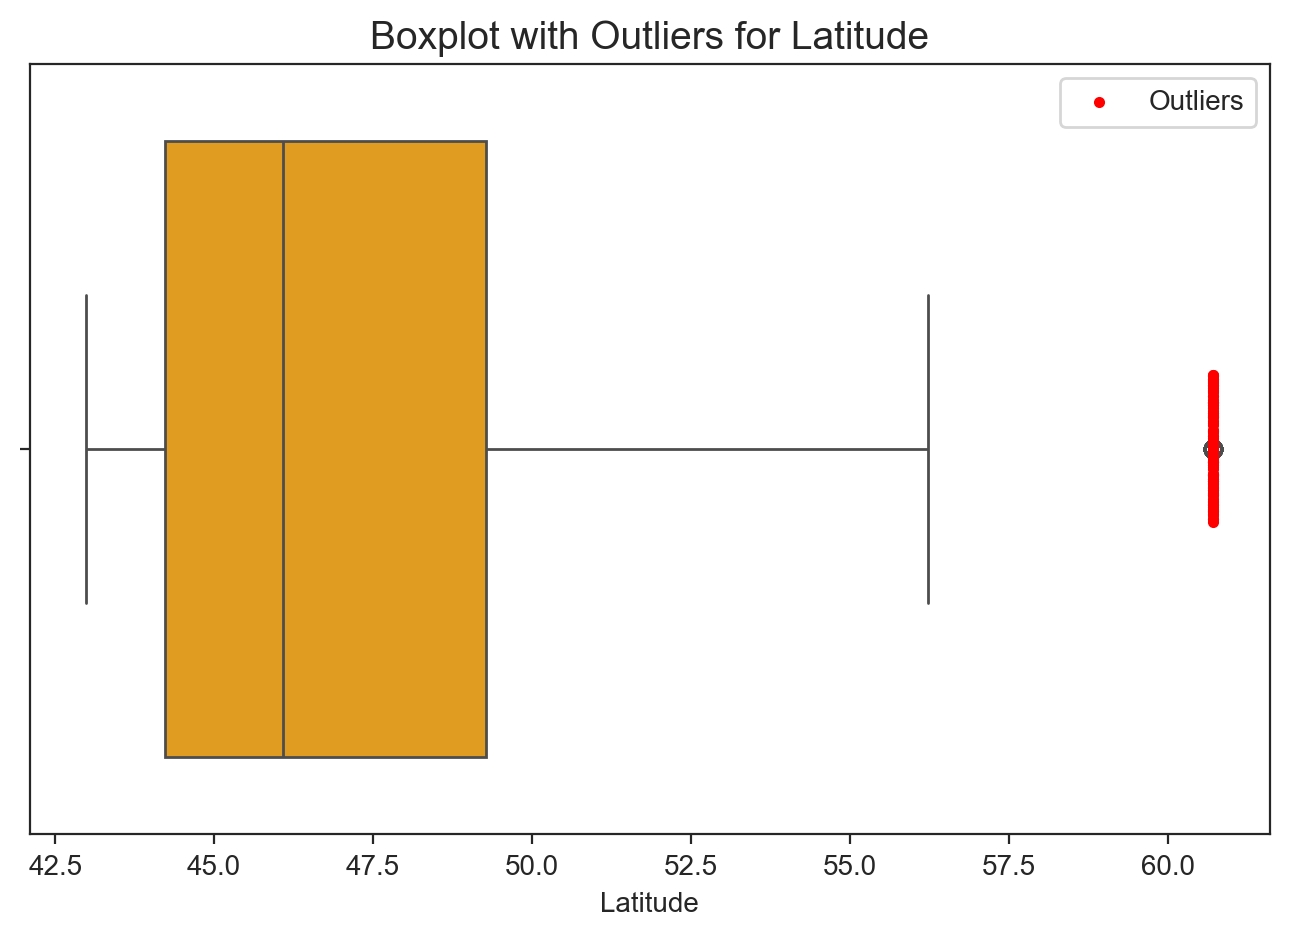

Column: Longitude - Number of Outliers: 0
Column: Longitude - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_43260\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


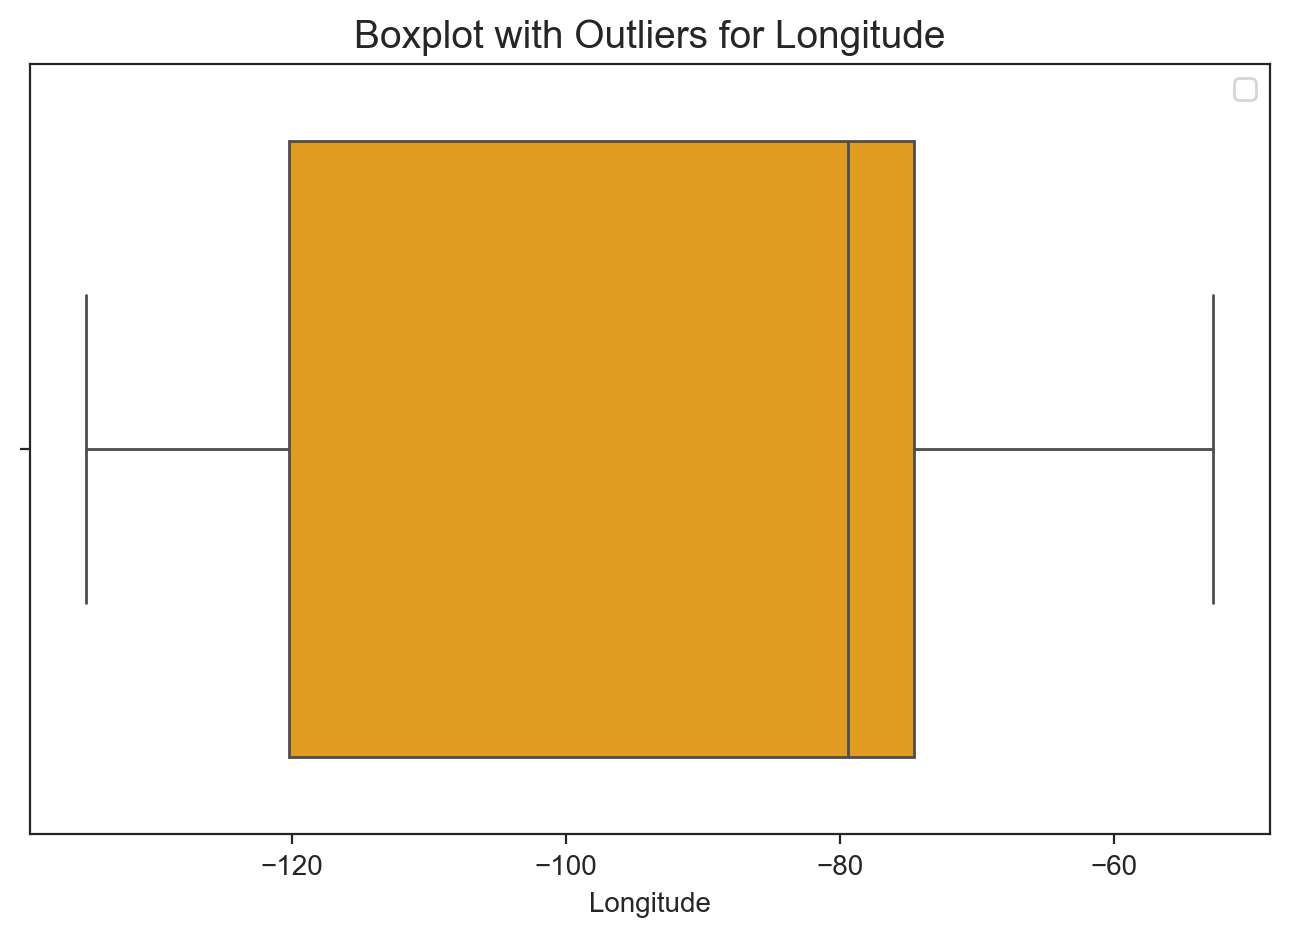

Column: Days_sub - Number of Outliers: 0
Column: Days_sub - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_43260\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


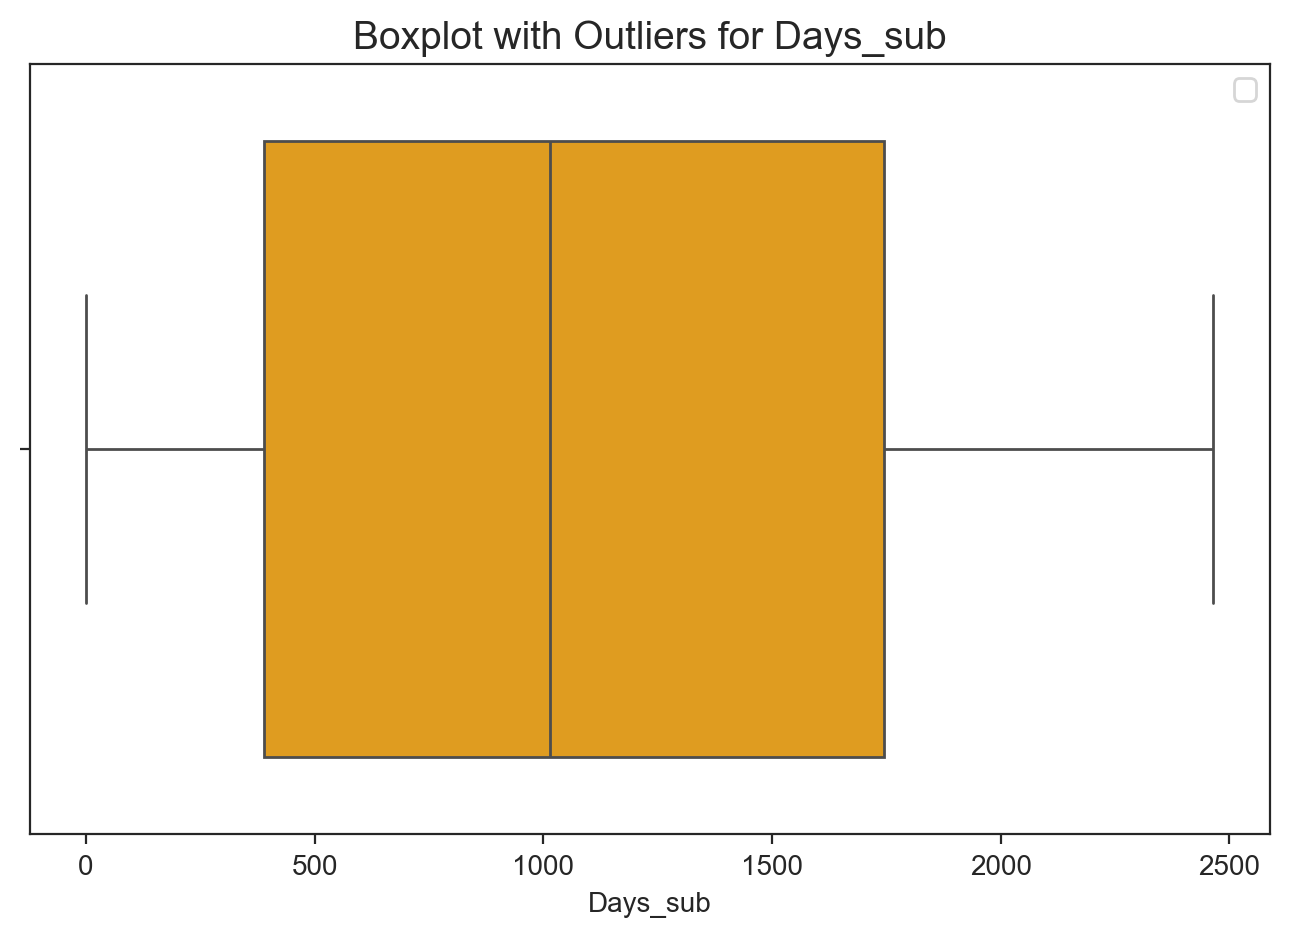

,Column,Num_Outliers,Pct_Outliers
0,Customer Lifetime Value,1460,8.798361
1,Latitude,108,0.650838


In [288]:
detect_outliers_iqr(df_c[c_metric], 0.001)

We only observe missing values for **Customer Lifetime Value** and **Latitude**.

In [289]:
df_c[df_c['Latitude']>60].sample(10)

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,Days_sub
15838,921530,Cristin,Weidler,Cristin Weidler,Canada,Yukon,Whitehorse,60.721188,-135.05684,Y2K 6R0,male,Bachelor,Rural,24195,Married,Star,10793.76,Standard,1239
5513,883056,Michelina,Boever,Michelina Boever,Canada,Yukon,Whitehorse,60.721188,-135.05684,Y2K 6R0,male,College,Rural,0,Married,Nova,3885.46,Standard,160
14200,804557,Frederic,Reasons,Frederic Reasons,Canada,Yukon,Whitehorse,60.721188,-135.05684,Y2K 6R0,female,Bachelor,Rural,93715,Married,Star,6044.02,Standard,594
3416,187318,Kendra,Mcclaren,Kendra Mcclaren,Canada,Yukon,Whitehorse,60.721188,-135.05684,Y2K 6R0,female,College,Suburban,0,Single,Aurora,13024.13,Standard,2428
8843,232395,Michal,Amsdell,Michal Amsdell,Canada,Yukon,Whitehorse,60.721188,-135.05684,Y2K 6R0,male,College,Rural,0,Divorced,Nova,10759.40,Standard,1770
14684,129328,Sherill,Henschke,Sherill Henschke,Canada,Yukon,Whitehorse,60.721188,-135.05684,Y2K 6R0,female,Bachelor,Suburban,61584,Married,Star,7379.46,Standard,242
3152,840376,Teisha,Ceo,Teisha Ceo,Canada,Yukon,Whitehorse,60.721188,-135.05684,Y2K 6R0,male,Bachelor,Rural,35601,Single,Aurora,10620.49,Standard,744
14043,909547,Ashlie,Forson,Ashlie Forson,Canada,Yukon,Whitehorse,60.721188,-135.05684,Y2K 6R0,female,Bachelor,Suburban,30968,Married,Star,5759.01,2021 Promotion,265
10910,119997,Efrain,Adame,Efrain Adame,Canada,Yukon,Whitehorse,60.721188,-135.05684,Y2K 6R0,male,Bachelor,Urban,24744,Divorced,Star,2514.28,Standard,702
16215,341942,Kent,Bennet,Kent Bennet,Canada,Yukon,Whitehorse,60.721188,-135.05684,Y2K 6R0,male,Bachelor,Suburban,31794,Divorced,Star,14137.23,Standard,1847


We won't take action on this, since they're all from the same city.

In [290]:
df_c[df_c['Customer Lifetime Value']>50000].sample(10)

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,Days_sub
9884,844145,Tabitha,Simonds,Tabitha Simonds,Canada,Ontario,Toronto,43.653225,-79.383186,P1J 8T7,female,College,Urban,0,Single,Nova,74228.52,Standard,210
4149,364710,Estella,Hymes,Estella Hymes,Canada,Quebec,Tremblant,46.118462,-74.596184,H5Y 2S9,female,Bachelor,Urban,25167,Married,Aurora,51016.07,2021 Promotion,270
4158,592992,Jacinto,Mcgranor,Jacinto Mcgranor,Canada,Ontario,Trenton,44.101128,-77.576309,K8V 4B2,male,College,Urban,0,Married,Aurora,61850.19,Standard,2000
4154,977244,Sharda,Delcour,Sharda Delcour,Canada,Quebec,Montreal,45.501690,-73.567253,H2T 9K8,female,Bachelor,Urban,77237,Married,Aurora,56675.94,Standard,1366
16898,776187,Janina,Lumb,Janina Lumb,Canada,British Columbia,Vancouver,49.282730,-123.120740,V5R 1W3,male,College,Urban,0,Single,Star,74228.52,Standard,1742
16895,900501,Genevieve,Sayyed,Genevieve Sayyed,Canada,Ontario,Sudbury,46.522099,-80.953033,M5V 1G5,male,College,Rural,0,Single,Star,61134.68,Standard,2296
9878,618524,Jen,Titsworth,Jen Titsworth,Canada,Ontario,Toronto,43.653225,-79.383186,P2T 6G3,male,Bachelor,Urban,24964,Married,Nova,58753.88,Standard,1864
9880,912633,Aleisha,Andrino,Aleisha Andrino,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3Z3,female,College,Rural,0,Married,Nova,60556.19,2021 Promotion,322
4159,179870,Inge,Brunn,Inge Brunn,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 2W2,female,Bachelor,Rural,33481,Single,Aurora,66025.75,Standard,546
9875,106936,Sarah,Spraque,Sarah Spraque,Canada,Ontario,Kingston,44.231171,-76.485954,M9K 2P4,female,Bachelor,Rural,48367,Married,Nova,57520.50,Standard,2246


NAO FIZ ESTA PARTE, NAO ACHEI A MELHOR MANEIRA DE LIDAR

## Merge both datasets

In [291]:
df_merged = df_f.merge(df_c, on='Loyalty#', how='left')

In [292]:
df_merged

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,...,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,Days_sub
0,413052,2021,12,2021-12-01,2,2,9384.0,938.00,0.0,0.0,...,V6T 1Y8,male,Bachelor,Urban,64429,Married,Star,15923.96,Standard,1314
1,464105,2021,12,2021-12-01,0,0,0.0,0.00,0.0,0.0,...,R2C 0M5,female,Bachelor,Urban,84981,Married,Nova,3878.77,Standard,1335
2,681785,2021,12,2021-12-01,10,3,14745.0,1474.00,0.0,0.0,...,V1E 4R6,male,Doctor,Urban,21986,Divorced,Star,2395.57,Standard,1651
3,185013,2021,12,2021-12-01,16,4,26311.0,2631.00,3213.0,32.0,...,E3B 2H2,female,Bachelor,Rural,67780,Divorced,Nova,7284.36,Standard,1403
4,216596,2021,12,2021-12-01,9,0,19275.0,1927.00,0.0,0.0,...,V6E 3Z3,male,Bachelor,Suburban,74034,Divorced,Nova,2862.18,2021 Promotion,330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596659,999902,2019,12,2019-12-01,7,0,30766.5,3076.65,0.0,0.0,...,M1R 4K3,male,College,Urban,0,Married,Aurora,7290.07,Standard,1681
596660,999911,2019,12,2019-12-01,0,0,0.0,0.00,0.0,0.0,...,A1C 6H9,male,Doctor,Suburban,23506,Single,Nova,8564.77,Standard,2342
596661,999940,2019,12,2019-12-01,14,0,18261.0,1826.10,0.0,0.0,...,G1B 3L5,female,Bachelor,Suburban,21542,Married,Nova,20266.50,Standard,523
596662,999982,2019,12,2019-12-01,0,0,0.0,0.00,0.0,0.0,...,V10 6T5,male,College,Urban,0,Married,Star,2631.56,Standard,177


In [293]:
df_merged.dtypes

Loyalty#                             int64
Year                                 int64
Month                                int64
YearMonthDate               datetime64[ns]
NumFlights                           int64
NumFlightsWithCompanions             int64
DistanceKM                         float64
PointsAccumulated                  float64
PointsRedeemed                     float64
DollarCostPointsRedeemed           float64
AvgFlightDistance_month            float64
First Name                          object
Last Name                           object
Customer Name                       object
Country                             object
Province or State                   object
City                                object
Latitude                           float64
Longitude                          float64
Postal code                         object
Gender                              object
Education                           object
Location Code                       object
Income     

In [294]:
metric = ['NumFlights','NumFlightsWithCompanions','DistanceKM','PointsAccumulated','PointsRedeemed','DollarCostPointsRedeemed','AvgFlightDistance_month','Income','Customer Lifetime Value',
          'Days_sub']

SE CALHAR ANTES DO SCALING PODIAMOS FAZER UMA COISA TIPO COMO A NOSSA STORA FEZ NO TRABALHO DELA, NA PARTE DE FEATURE ENGENEERING

## Scaling

MinMax ou Standard???

In [297]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the data and transform it
df_merged_scaled = scaler.fit_transform(df_merged[metric])

# Convert scaled data into a DataFrame with the same index as the original DataFrame
df_merged_scaled_df = pd.DataFrame(df_merged_scaled, columns=metric, index=df_merged.index)

# Select the non-metric features from the original data
non_metric_features = df_merged.drop(columns=metric)

# Combine the scaled metric features with the non-metric features (ensure no new rows are added)
df_combined = pd.concat([df_merged_scaled_df, non_metric_features], axis=1)

In [298]:
df_combined.sample(10)

,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month,Income,Customer Lifetime Value,Days_sub,...,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Marital Status,LoyaltyStatus,EnrollmentType
300472,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.400396,0.090243,0.645030,...,Tremblant,46.118462,-74.596184,H5Y 2S9,female,Bachelor,Urban,Married,Nova,Standard
275316,0.142857,0.272727,0.565580,0.565414,0.0,0.0,0.195281,0.963243,0.069032,0.722110,...,Vancouver,49.282730,-123.120740,V1E 4R6,female,Bachelor,Urban,Divorced,Nova,Standard
460111,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.698223,0.011023,0.856389,...,Trenton,44.101128,-77.576309,K8V 4B2,female,Bachelor,Suburban,Married,Star,Standard
369259,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.373151,0.033206,0.098174,...,Victoria,48.428421,-123.365650,V10 6T5,female,Bachelor,Urban,Married,Star,Standard
591147,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.240696,0.082675,0.542799,...,Toronto,43.653225,-79.383186,M1R 4K3,female,Bachelor,Rural,Divorced,Star,Standard
7586,0.380952,0.727273,0.374239,0.374167,0.0,0.0,0.048456,0.000000,0.028208,0.378905,...,Winnipeg,49.895138,-97.138374,R6Y 4T5,female,College,Rural,Single,Nova,Standard
554852,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.283654,0.084472,0.077079,...,Vancouver,49.282730,-123.120740,V6E 3Z3,male,Bachelor,Suburban,Married,Aurora,Standard
23035,0.142857,0.000000,0.206304,0.206232,0.0,0.0,0.071231,0.529901,0.007996,0.339148,...,Whistler,50.116322,-122.957360,V6T 1Y8,female,Bachelor,Rural,Married,Star,Standard
552314,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.007516,0.175254,...,Vancouver,49.282730,-123.120740,V5R 1W3,male,College,Rural,Single,Star,Standard
592119,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.373911,0.025992,0.137120,...,Moncton,46.087818,-64.778229,E1A 2A7,male,Bachelor,Suburban,Married,Nova,Standard


## Missing Values

In [ ]:
df_c.isna().sum()

Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14329
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

Missing "CancellationDate" values means that the customer hasn't cancelled the programm yet.

In [ ]:
df_f.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

In [ ]:
df_f.sample(10)

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
153285,464771,2021,5,2021-05-01,0,0,0.0,0.00,0.0,0.0
280673,458640,2021,2,2021-02-01,0,0,0.0,0.00,0.0,0.0
490180,102464,2019,6,2019-06-01,5,4,12635.1,1263.51,5790.6,57.6
60619,923680,2020,3,2020-03-01,8,1,12307.0,1230.00,0.0,0.0
223727,709948,2021,7,2021-07-01,14,0,8760.0,876.00,0.0,0.0
572480,883505,2019,10,2019-10-01,4,4,21684.6,2168.46,0.0,0.0
12120,451425,2020,5,2020-05-01,0,0,0.0,0.00,0.0,0.0
534917,684133,2019,8,2019-08-01,11,0,7159.5,715.95,0.0,0.0
13181,350979,2020,5,2020-05-01,6,1,14948.0,1494.00,0.0,0.0
596368,358039,2019,12,2019-12-01,0,0,0.0,0.00,0.0,0.0


We will impute the missing values using the KNN imputer.

In [ ]:
imputer = KNNImputer(n_neighbors=5, weights="uniform")

imputer.fit(df_c[c_metric])
df_c[c_metric] = imputer.transform(df_c[c_metric])

In [ ]:
df_c.isna().sum()

Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                         0
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14329
Customer Lifetime Value        0
EnrollmentType                 0
dtype: int64

## Encoding of categorical features